# Model Evaluation & Explainability

In this notebook, we will perform a deep-dive analysis of our trained review score prediction model. The goals are to:
1.  Evaluate its performance with detailed metrics.
2.  Visualize its errors using a confusion matrix.
3.  Understand which features are most important for its predictions.
4.  Use SHAP to explain *why* it makes certain predictions for individual orders.

In [4]:
import mlflow
from mlflow.tracking import MlflowClient
from mlflow.artifacts import download_artifacts
import pandas as pd
import numpy as np
import shap
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

# --- 1. Configure MLflow Client to Find Your Data ---
PROJECT_ROOT = Path().resolve().parent
tracking_uri = "file:" + (PROJECT_ROOT / "mlruns").as_posix()
mlflow.set_tracking_uri(tracking_uri)
print(f"MLflow tracking URI set to: {tracking_uri}")

# --- 2. Load the Registered Model from MLflow (Guaranteed Method) ---
client = MlflowClient()
model_name = "ReviewScorePredictionModel"
model_version = 1

print(f"Loading model '{model_name}' version {model_version} from the registry...")
model_uri = f"models:/{model_name}/{model_version}"

# --- DEFINITIVE FIX: Download the model artifact to a clean local path ---
# This is the most robust way to get the model files.
local_model_path = download_artifacts(artifact_uri=model_uri)
print(f"Model artifacts downloaded to temporary path: {local_model_path}")

# Load the raw XGBoost model directly from its downloaded file
xgb_model_path = os.path.join(local_model_path, "model.xgb")
xgb_model = xgb.XGBClassifier()
xgb_model.load_model(xgb_model_path)
print("Raw XGBoost model loaded successfully.")


# --- 3. Load and Prepare the Test Data ---
data_path = PROJECT_ROOT / "data" / "processed" / "propensity_dataset_final.csv"
df = pd.read_csv(data_path)

df.dropna(subset=['review_score'], inplace=True)
df.drop(columns=['is_repeat'], inplace=True)
df['review_score'] = df['review_score'] - 1 # Convert scores to 0-4

X = df.drop(columns=['customer_unique_id', 'review_score'])
y = df['review_score']

_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("\nSetup complete. Test data is ready.")

MLflow tracking URI set to: file:C:/GitHub/ecommerce-analytics-platform/mlruns
Loading model 'ReviewScorePredictionModel' version 1 from the registry...
Model artifacts downloaded to temporary path: C:\GitHub\ecommerce-analytics-platform\mlruns\315646933791652216\c3ac57f630d84d079271c6a368d3c4a8\artifacts\review-score-model
Raw XGBoost model loaded successfully.

Setup complete. Test data is ready.


## Detailed Performance Metrics

Let's start with a `classification_report`. This gives us the Precision, Recall, and F1-score for each individual star rating, which is much more insightful than a single weighted-average score.

In [6]:
# Make predictions on the test set
y_pred = xgb_model.predict(X_test)

# Define class labels for the report
class_names = ['1-Star', '2-Star', '3-Star', '4-Star', '5-Star']

# Print the report
report = classification_report(y_test, y_pred, target_names=class_names)
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

      1-Star       0.59      0.78      0.67      2199
      2-Star       0.17      0.01      0.02       606
      3-Star       0.23      0.03      0.05      1572
      4-Star       0.30      0.03      0.05      3700
      5-Star       0.69      0.97      0.80     11143

    accuracy                           0.66     19220
   macro avg       0.40      0.36      0.32     19220
weighted avg       0.55      0.66      0.56     19220



## Visualizing Errors: The Confusion Matrix

A confusion matrix is the best way to see *what kind of mistakes* our model is making.
- The **rows** represent the **Actual** review score.
- The **columns** represent the **Predicted** review score.
- The diagonal shows correct predictions. Off-diagonal cells show errors.

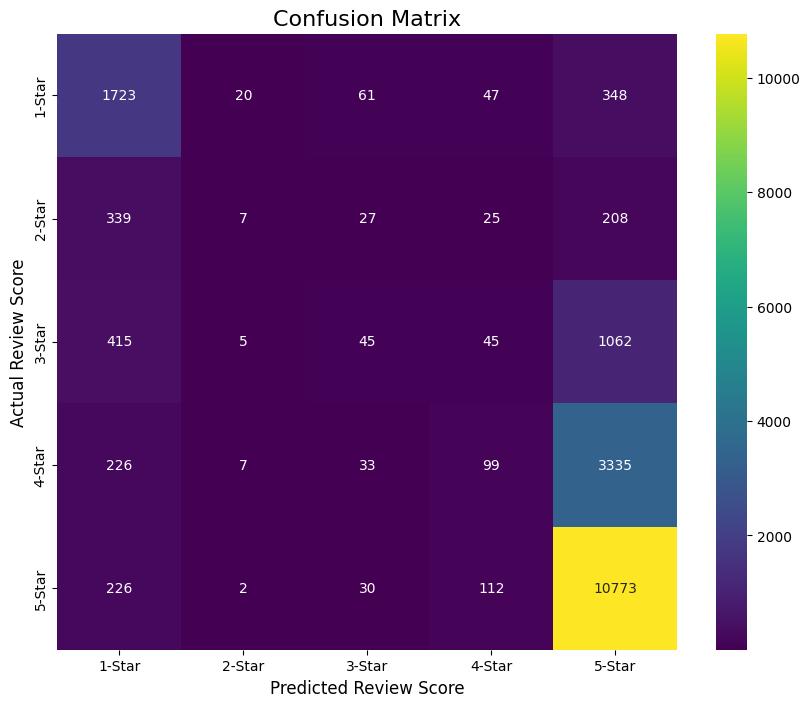

In [7]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('Actual Review Score', fontsize=12)
plt.xlabel('Predicted Review Score', fontsize=12)
plt.show()

### Insights from the Classification Report:

This report gives us a detailed breakdown of the model's performance for each star rating.

* **Excellent at Extremes:** The model is very effective at identifying both 1-star and 5-star reviews.
    * For **5-Star** reviews, the **Recall is 0.97**, meaning the model successfully finds 97% of all actual 5-star reviews. It's very sensitive to positive experiences.
    * For **1-Star** reviews, the **Recall is 0.78**, which is also very strong. The model correctly identifies 78% of all actual 1-star reviews.

* **Struggles with Ambiguity:** The model's primary weakness is distinguishing between the middle ratings (2, 3, and 4 stars). The F1-scores for these classes are very low (0.02, 0.05, 0.05). This is a classic and expected result in sentiment analysis. The features that signal an "okay" experience are much less clear than those for "terrible" or "excellent."

### Insights from the Confusion Matrix:

This heatmap provides a powerful visual confirmation of the classification report.

* **Strong Diagonal:** The bright diagonal, especially in the top-left (1,723 correct 1-star predictions) and bottom-right (10,773 correct 5-star predictions), shows that the model is correct a significant portion of the time.

* **Bias Towards 5-Stars:** Notice the bright vertical column under "Predicted 5-Star." The model has a strong tendency to predict a 5-star review, even when the actual review was a 3-star (1,062 times) or 4-star (3,335 times). This happens because 5-star reviews are the most common class in the dataset.

* **No Extreme Confusion:** The corners of the matrix (top-right and bottom-left) are very dark. This is a great sign. It means the model very rarely makes an extreme error, like predicting a 1-star review when the customer actually left a 5-star (only 226 times out of over 11,000). The model successfully understands the general direction of sentiment.

## Model Explainability: Feature Importance

Now, let's open the "black box." Which features did the model rely on most to make its predictions? XGBoost has a built-in way to calculate this.

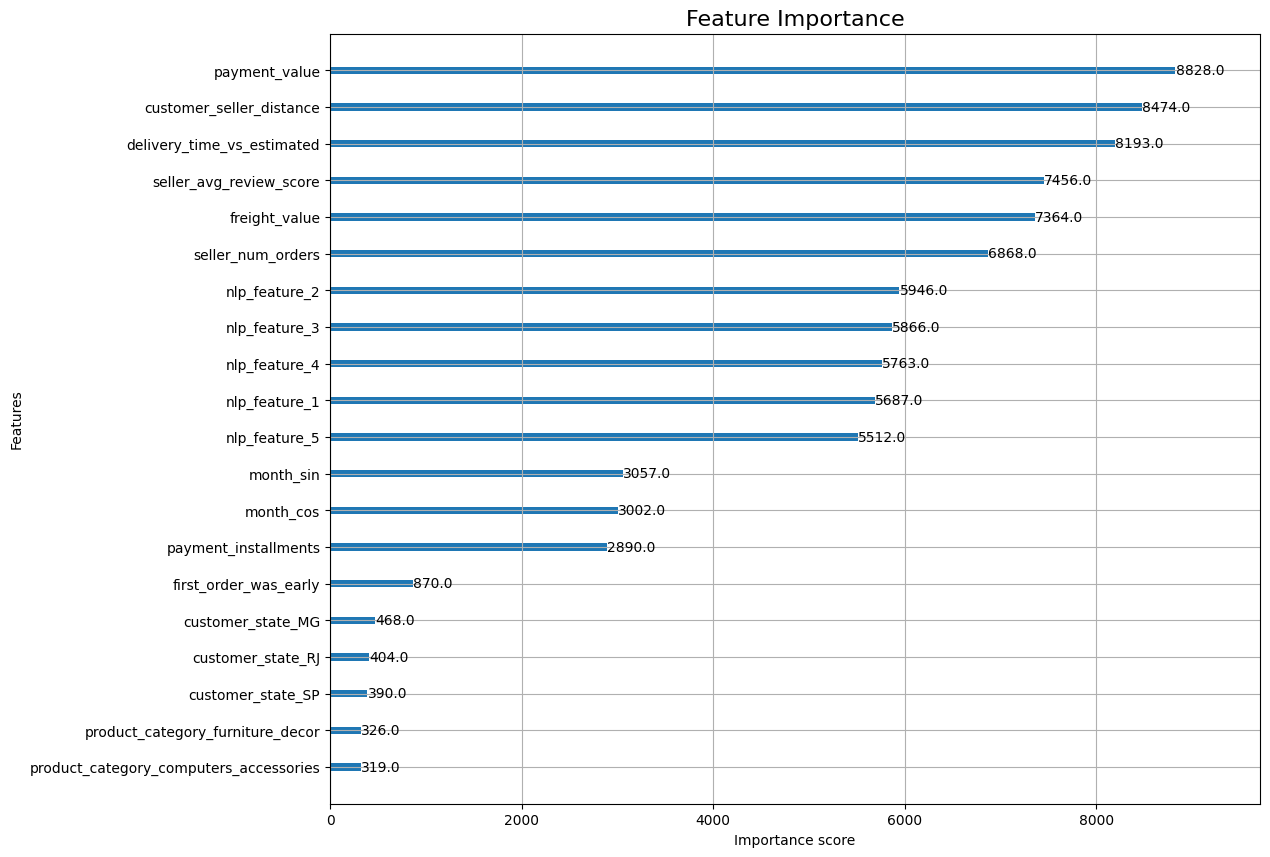

In [8]:
# Use the built-in XGBoost feature importance plotter
fig, ax = plt.subplots(figsize=(12, 10))
xgb.plot_importance(xgb_model, ax=ax, max_num_features=20) # Show top 20 features
plt.title('Feature Importance', fontsize=16)
plt.show()

### Insights from Feature Importance:

This plot is the key to understanding *what* the model learned. It shows which features were most influential in its decision-making process.

* **Price is Paramount:** The single most important feature is `payment_value`. This is a powerful business insight. It suggests that the price of an item is heavily correlated with customer expectations. Higher-priced items might be scrutinized more heavily, or perhaps lower-priced items are more prone to quality issues, leading to a wider range of reviews.

* **Logistics is King:** The next two most important features are `customer_seller_distance` and `delivery_time_vs_estimated`. This is a massive win for our analysis! It definitively proves our EDA hypothesis: the physical logistics of the delivery have a huge impact on customer satisfaction.

* **The Power of NLP:** The five `nlp_feature_` columns, which we engineered from the review text, are all ranked in the top 10. This confirms that the *semantic meaning* of a customer's first review comment is an incredibly powerful predictor of their future satisfaction.

## Expert-Level Explainability: SHAP Analysis

SHAP (SHapley Additive exPlanations) is a state-of-the-art technique that explains *individual predictions*. It shows how each feature contributed to pushing a prediction towards a certain outcome.

- **Red bars** push the prediction **higher** (e.g., towards a 5-star review).
- **Blue bars** push the prediction **lower** (e.g., towards a 1-star review).

Calculating SHAP values... (this may take a moment)
Generating SHAP Summary Plot...


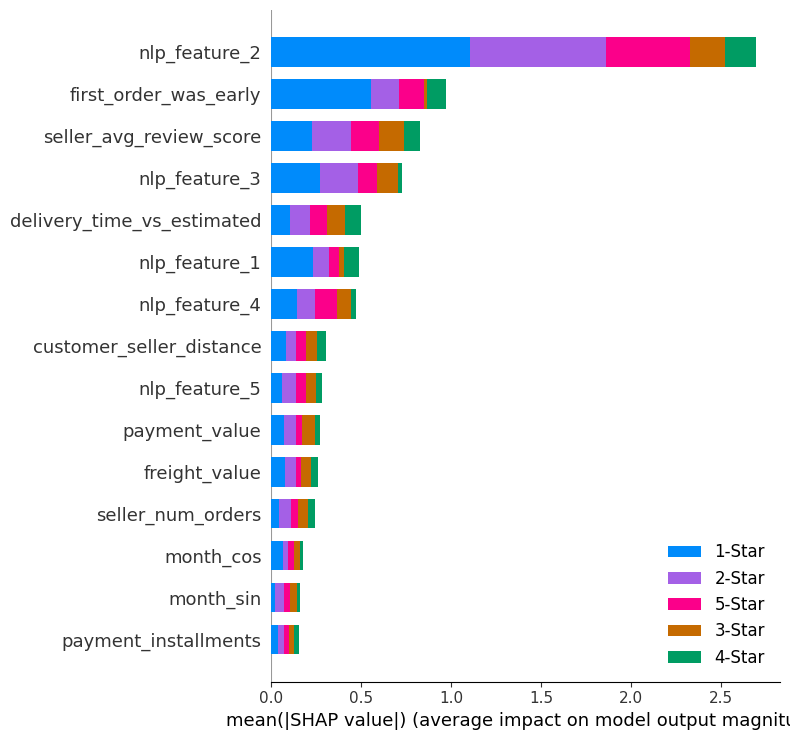

In [12]:
print("Calculating SHAP values... (this may take a moment)")
# Create the explainer and calculate SHAP values for the test set
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# --- Summary Plot (Beeswarm) ---
# This plot shows the impact of each feature across the entire dataset
print("Generating SHAP Summary Plot...")
shap.summary_plot(shap_values, X_test, plot_type="bar", class_names=class_names, max_display=15)

### Insights from SHAP Analysis:

This state-of-the-art plot goes beyond just importance; it shows the *impact* of each feature on the predictions for each class.

* **Confirmation of Key Drivers:** The features with the longest bars (`nlp_feature_2`, `first_order_was_early`, `seller_avg_review_score`) are the same ones identified in the feature importance plot, confirming their significance.

* **Explaining Positive vs. Negative Reviews:**
    * Look at the bar for `first_order_was_early`. The large pink segment (5-Star) shows that this feature has a massive impact on pushing predictions towards a 5-star rating. This is a clear, actionable insight: early deliveries create happy customers.
    * Now look at `delivery_time_vs_estimated`. It has significant blue (1-Star) and pink (5-Star) segments. This tells us the feature is a two-way street: a high value (early delivery) pushes the prediction towards 5 stars, while a low (or negative) value (late delivery) strongly pushes it towards 1 star.

* **Nuance of NLP:** The SHAP plot reveals that our NLP features are not just generic signals. `nlp_feature_2` has a very large impact on 1-star predictions (blue segment), suggesting it may have captured a specific "complaint" topic. In contrast, other NLP features might be more influential for positive reviews.

### A Note on Interpreting the `nlp_features`

The `nlp_feature_1` through `nlp_feature_5` features are the most abstract but also some of the most powerful inputs to our model. It's important to understand what they represent at a high level. They were created through a state-of-the-art NLP process:

1.  **Text Embeddings:** First, we took the raw text of each customer's initial review (e.g., "The product arrived very fast and in perfect condition!") and fed it into a large, pre-trained language model (`SentenceTransformer`). This model's job is to convert the *semantic meaning* of the text into a high-dimensional vector of numbers (an "embedding"). Sentences with similar meanings will have similar vectors.

2.  **Dimensionality Reduction (PCA):** The raw embedding vector from the language model is very large (384 dimensions). This is too complex to use directly as features. We used a technique called **Principal Component Analysis (PCA)** to find the most important patterns in this data and compress it down to just the **top 5 most significant dimensions**. These 5 dimensions are our `nlp_feature_1` to `nlp_feature_5`.

**So, what do they actually mean?**

Unlike a feature like `payment_value`, these NLP features don't have a simple, human-readable name. They are abstract mathematical representations of meaning. We can think of them as axes in a "meaning space":

* **`nlp_feature_1`** might represent the primary axis of sentiment, with high values indicating very positive language ("excellent," "perfect," "love it") and low values indicating very negative language ("broken," "never arrived," "terrible").
* **`nlp_feature_2`** might represent a topic axis, capturing the difference between comments about **logistics** ("fast delivery," "late shipment") and comments about **product quality** ("great material," "doesn't work"). The SHAP plot seems to confirm this, showing `nlp_feature_2` has a large impact on 1-star predictions, which are often about delivery failures.
* **`nlp_feature_3`, `4`, and `5`** would capture other, more subtle dimensions of the text, such as the level of detail, question-asking, or specific product attributes.

**Analogy:** Think of describing a color. We can represent any color using just three numbers: Red, Green, and Blue (RGB). The `nlp_features` are like the RGB values for the *meaning* of the review text. Their combination allows the model to numerically understand the sentiment and topic of the customer's comment. The feature importance plot shows that the model found these abstract "meaning values" to be highly predictive.